<a href="https://colab.research.google.com/github/pabloofernandezz/An-lisis-Sector/blob/main/An%C3%A1lisis_Sector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📡 Descargando datos de Yahoo Finance...

  SAN.MC     BANCO SANTANDER S.A.
  BBVA.MC    BANCO BILBAO VIZCAYA ARGENTARIA
  BNP.PA     BNP PARIBAS ACT.A
  GLE.PA     SOCIETE GENERALE
  DBK.DE     DEUTSCHE BANK AG              N
  CBK.DE     Commerzbank AG                I
  UCG.MI     UNICREDIT
  ISP.MI     INTESA SANPAOLO

  SAN.MC     sin datos para: EV_EBITDA → se usará 0 en el score
  BBVA.MC    sin datos para: EV_EBITDA → se usará 0 en el score
  BNP.PA     sin datos para: EV_EBITDA → se usará 0 en el score
  GLE.PA     sin datos para: EV_EBITDA → se usará 0 en el score
  DBK.DE     sin datos para: EV_EBITDA → se usará 0 en el score
  CBK.DE     sin datos para: EV_EBITDA → se usará 0 en el score
  UCG.MI     sin datos para: EV_EBITDA → se usará 0 en el score
  ISP.MI     sin datos para: EV_EBITDA → se usará 0 en el score

✔ 8 empresas cargadas.



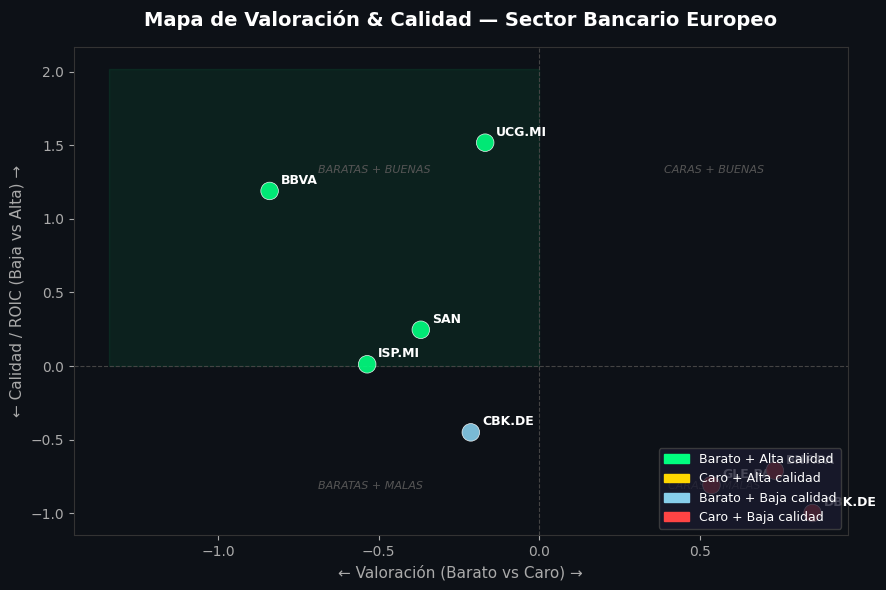

TOP 3 — Mejores oportunidades
 Rank  Ticker                         Empresa Score_Global   PE   ROE Momentum_6m
    1 BBVA.MC BANCO BILBAO VIZCAYA ARGENTARIA       10.000 8.5x 18.3%       17.1%
    2  UCG.MI                       UNICREDIT        9.430 7.7x 16.8%        1.1%
    3  SAN.MC            BANCO SANTANDER S.A.        6.880 8.2x 12.7%       14.8%

BOTTOM 3 — Peor posicionadas
 Rank Ticker                         Empresa Score_Global   PE   ROE Momentum_6m
    6 ISP.MI                 INTESA SANPAOLO        2.190 8.7x 14.3%       -1.4%
    7 CBK.DE Commerzbank AG                I        0.070 8.6x  8.0%       -2.3%
    8 DBK.DE DEUTSCHE BANK AG              N        0.000 6.6x  8.3%      -14.5%

RANKING COMPLETO
 Rank  Ticker                         Empresa Score_Global   PE   ROE Momentum_6m
    1 BBVA.MC BANCO BILBAO VIZCAYA ARGENTARIA       10.000 8.5x 18.3%       17.1%
    2  UCG.MI                       UNICREDIT        9.430 7.7x 16.8%        1.1%
    3  SAN.MC           

In [1]:
"""
╔══════════════════════════════════════════════════════════════════╗
║         SCRIPT 1: RANKING SECTORIAL MULTIFACTORIAL               ║
║         Proyecto Pablo & J. — Motor Cuantitativo                 ║
╚══════════════════════════════════════════════════════════════════╝
"""

# ─────────────────────────────────────────────────────────────────
# NECESARIO PARA QUE EL GRÁFICO APAREZCA EN COLAB
# ─────────────────────────────────────────────────────────────────
get_ipython().run_line_magic('matplotlib', 'inline')

# ─────────────────────────────────────────────────────────────────
# INSTALACIÓN AUTOMÁTICA
# ─────────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["yfinance", "pandas", "matplotlib", "scipy"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])


# ══════════════  CONFIG — CAMBIA AQUÍ  ═══════════════════════════

SECTOR_NOMBRE = "Sector Bancario Europeo"

TICKERS = [
    "SAN.MC",   # Santander        (España)
    "BBVA.MC",  # BBVA             (España)
    "BNP.PA",   # BNP Paribas      (Francia)
    "GLE.PA",   # Société Générale (Francia)
    "DBK.DE",   # Deutsche Bank    (Alemania)
    "CBK.DE",   # Commerzbank      (Alemania)
    "UCG.MI",   # UniCredit        (Italia)
    "ISP.MI",   # Intesa Sanpaolo  (Italia)
]

# ─────────────────────────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────
# 1. DESCARGA DE DATOS
# ─────────────────────────────────────────────────────────────────
print("📡 Descargando datos de Yahoo Finance...\n")

records = []
for ticker in TICKERS:
    try:
        info = yf.Ticker(ticker).info
        pe        = info.get("forwardPE") or info.get("trailingPE")
        pb        = info.get("priceToBook")
        ev_ebitda = info.get("enterpriseToEbitda")
        roe       = info.get("returnOnEquity")
        margins   = info.get("operatingMargins")
        hist = yf.Ticker(ticker).history(period="6mo")
        momentum_6m = (hist["Close"].iloc[-1] / hist["Close"].iloc[0] - 1) * 100 if len(hist) >= 2 else None
        name = info.get("shortName") or ticker
        records.append({
            "Ticker": ticker, "Empresa": name,
            "PE": pe, "PB": pb, "EV_EBITDA": ev_ebitda,
            "ROE": roe, "Margen_Op": margins, "Momentum_6m": momentum_6m,
        })
        print(f"  {ticker:10s} {name}")
    except Exception as e:
        print(f"   {ticker} — Error: {e}")

df = pd.DataFrame(records)

# Aviso de métricas faltantes por empresa
print()
metricas = ["PE", "PB", "EV_EBITDA", "ROE", "Margen_Op", "Momentum_6m"]
for _, row in df.iterrows():
    faltantes = [m for m in metricas if pd.isna(row[m])]
    if faltantes:
        print(f"  {row['Ticker']:10s} sin datos para: {', '.join(faltantes)} → se usará 0 en el score")

print(f"\n✔ {len(df)} empresas cargadas.\n")

# ─────────────────────────────────────────────────────────────────
# 2. Z-SCORE Y PUNTUACIÓN
#    NaN → 0 antes del zscore (= neutro, no penaliza ni premia)
# ─────────────────────────────────────────────────────────────────
def zscore_col(series, invert=False):
    s = pd.to_numeric(series, errors="coerce")
    # Rellenar NaN con la media de la columna → contribución neutra
    s_filled = s.fillna(s.mean())
    mean = s_filled.mean()
    std  = s_filled.std()
    z = (s_filled - mean) / std if std > 0 else pd.Series(np.zeros(len(s_filled)), index=s.index)
    return -z if invert else z

df["z_PE"]       = zscore_col(df["PE"],        invert=True)
df["z_PB"]       = zscore_col(df["PB"],        invert=True)
df["z_EVEBITDA"] = zscore_col(df["EV_EBITDA"], invert=True)
df["z_ROE"]      = zscore_col(df["ROE"])
df["z_Margen"]   = zscore_col(df["Margen_Op"])
df["z_Mom"]      = zscore_col(df["Momentum_6m"])

PESOS = {"z_PE": 0.15, "z_PB": 0.10, "z_EVEBITDA": 0.10,
         "z_ROE": 0.25, "z_Margen": 0.15, "z_Mom": 0.25}

df["Score_Raw"]  = sum(df[col] * w for col, w in PESOS.items())
df["Eje_X"] = (df["z_PE"] + df["z_PB"] + df["z_EVEBITDA"]) / 3
df["Eje_Y"] = (df["z_ROE"] + df["z_Margen"]) / 2
df = df.sort_values("Score_Raw", ascending=False).reset_index(drop=True)
df["Rank"] = range(1, len(df) + 1)

# Reescalar Score a 0-10 (sin forzar extremos en 0 y 10)
s_min = df["Score_Raw"].min()
s_max = df["Score_Raw"].max()
if s_max > s_min:
    df["Score_Global"] = ((df["Score_Raw"] - s_min) / (s_max - s_min) * 10).round(2)
else:
    df["Score_Global"] = 5.0

# ─────────────────────────────────────────────────────────────────
# 3. SCATTER PLOT
# ─────────────────────────────────────────────────────────────────
DARK_BG = "#0D1117"

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

ax.axhline(0, color="#444", linewidth=0.8, linestyle="--")
ax.axvline(0, color="#444", linewidth=0.8, linestyle="--")

y_max = df["Eje_Y"].max() + 0.5
x_min = df["Eje_X"].min() - 0.5
ax.fill_betweenx([0, y_max], x_min, 0, alpha=0.07, color="#00FF7F")

cfg = dict(fontsize=8, color="#555", style="italic")
pad = 0.15
ax.text(df["Eje_X"].min() + pad, df["Eje_Y"].max() - pad, "BARATAS + BUENAS ", **cfg, ha="left",  va="top")
ax.text(df["Eje_X"].max() - pad, df["Eje_Y"].max() - pad, "CARAS + BUENAS",      **cfg, ha="right", va="top")
ax.text(df["Eje_X"].min() + pad, df["Eje_Y"].min() + pad, "BARATAS + MALAS",     **cfg, ha="left",  va="bottom")
ax.text(df["Eje_X"].max() - pad, df["Eje_Y"].min() + pad, "CARAS + MALAS ",    **cfg, ha="right", va="bottom")

colors = []
for _, row in df.iterrows():
    if   row["Eje_X"] < 0 and row["Eje_Y"] > 0: colors.append("#00FF7F")
    elif row["Eje_X"] > 0 and row["Eje_Y"] > 0: colors.append("#FFD700")
    elif row["Eje_X"] < 0 and row["Eje_Y"] < 0: colors.append("#87CEEB")
    else:                                         colors.append("#FF4444")

ax.scatter(df["Eje_X"], df["Eje_Y"], c=colors, s=160, zorder=5,
           edgecolors="white", linewidths=0.5, alpha=0.9)

for _, row in df.iterrows():
    ax.annotate(row["Ticker"].replace(".MC", ""),
                (row["Eje_X"], row["Eje_Y"]),
                textcoords="offset points", xytext=(8, 5),
                fontsize=9, color="white", fontweight="bold")

ax.set_xlabel("← Valoración (Barato vs Caro) →", color="#AAA", fontsize=11)
ax.set_ylabel("← Calidad / ROIC (Baja vs Alta) →", color="#AAA", fontsize=11)
ax.set_title(f"Mapa de Valoración & Calidad — {SECTOR_NOMBRE}",
             color="white", fontsize=14, fontweight="bold", pad=15)
ax.tick_params(colors="#AAA")
for spine in ax.spines.values():
    spine.set_edgecolor("#333")

legend_elements = [
    mpatches.Patch(color="#00FF7F", label="Barato + Alta calidad"),
    mpatches.Patch(color="#FFD700", label="Caro + Alta calidad"),
    mpatches.Patch(color="#87CEEB", label="Barato + Baja calidad"),
    mpatches.Patch(color="#FF4444", label="Caro + Baja calidad"),
]
ax.legend(handles=legend_elements, loc="lower right",
          facecolor="#1A1A2E", edgecolor="#444", labelcolor="white", fontsize=9)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────
# 4. TABLAS Y RANKING
# ─────────────────────────────────────────────────────────────────
cols_mostrar = ["Rank", "Ticker", "Empresa", "Score_Global", "PE", "ROE", "Momentum_6m"]

def formatear_tabla(dataframe):
    d = dataframe[cols_mostrar].copy()
    d["Score_Global"] = d["Score_Global"].apply(lambda x: f"{x:.3f}")
    d["PE"]           = d["PE"].apply(lambda x: f"{x:.1f}x" if pd.notna(x) else "N/A")
    d["ROE"]          = d["ROE"].apply(lambda x: f"{x*100:.1f}%" if pd.notna(x) else "N/A")
    d["Momentum_6m"]  = d["Momentum_6m"].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "N/A")
    return d

print("=" * 68)
print("TOP 3 — Mejores oportunidades")
print("=" * 68)
print(formatear_tabla(df.head(3)).to_string(index=False))

print()
print("=" * 68)
print("BOTTOM 3 — Peor posicionadas")
print("=" * 68)
print(formatear_tabla(df.tail(3)).to_string(index=False))

print()
print("=" * 68)
print("RANKING COMPLETO")
print("=" * 68)
print(formatear_tabla(df).to_string(index=False))